# **Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

Data Loading

In [2]:
df = pd.read_excel('premiums_young.xlsx')

In [3]:
df.shape

(20096, 13)

In [4]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [5]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033
std,2.294050,0.940767,23.418644,2749.609551
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [6]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [7]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20096 non-null  int64 
 1   gender                 20096 non-null  object
 2   region                 20096 non-null  object
 3   marital_status         20096 non-null  object
 4   number_of_dependants   20096 non-null  int64 
 5   bmi_category           20096 non-null  object
 6   smoking_status         20094 non-null  object
 7   employment_status      20095 non-null  object
 8   income_level           20092 non-null  object
 9   income_lakhs           20096 non-null  int64 
 10  medical_history        20096 non-null  object
 11  insurance_plan         20096 non-null  object
 12  annual_premium_amount  20096 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 2.0+ MB


In [9]:
df.isna().mean()*100

age                      0.000000
gender                   0.000000
region                   0.000000
marital_status           0.000000
number_of_dependants     0.000000
bmi_category             0.000000
smoking_status           0.009952
employment_status        0.004976
income_level             0.019904
income_lakhs             0.000000
medical_history          0.000000
insurance_plan           0.000000
annual_premium_amount    0.000000
dtype: float64

In [10]:
df['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L', nan], dtype=object)

In [11]:
df[df['income_level'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
379,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191
7634,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,NaN,NaN,8,No Disease,Bronze,5873
9813,18,Male,Southwest,Married,3,Normal,Occasional,Freelancer,NaN,6,No Disease,Silver,8484
15037,19,Male,Southeast,Unmarried,0,Overweight,Occasional,Salaried,NaN,3,No Disease,Silver,9174


In [12]:
df['employment_status'].unique()

array(['Self-Employed', 'Freelancer', 'Salaried', nan], dtype=object)

In [13]:
df['medical_history'].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [14]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
6853,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001
7757,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010


In [15]:
df[(df['medical_history'] == 'High blood pressure & Heart disease') & (df['bmi_category'] == 'Overweight')]['smoking_status'].mode()

0    No Smoking
Name: smoking_status, dtype: object

In [16]:
smoking_mode = (
    df.groupby(['medical_history', 'bmi_category'])['smoking_status']
    .agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else None)
    .reset_index()
)

print(smoking_mode)

                        medical_history bmi_category smoking_status
0                              Diabetes       Normal     No Smoking
1                              Diabetes      Obesity     No Smoking
2                              Diabetes   Overweight     No Smoking
3                              Diabetes  Underweight     No Smoking
4              Diabetes & Heart disease       Normal     No Smoking
5              Diabetes & Heart disease      Obesity     No Smoking
6              Diabetes & Heart disease   Overweight     No Smoking
7              Diabetes & Heart disease  Underweight     No Smoking
8        Diabetes & High blood pressure       Normal     No Smoking
9        Diabetes & High blood pressure      Obesity     No Smoking
10       Diabetes & High blood pressure   Overweight     No Smoking
11       Diabetes & High blood pressure  Underweight     No Smoking
12                   Diabetes & Thyroid       Normal     No Smoking
13                   Diabetes & Thyroid      Obe

In [17]:
"""
Handling Missing Values:

- income_level:
  Missingness is likely dependent on the observed feature income_lakhs,
  as both represent income information. Hence, this is classified as MAR
  (Missing At Random). I impute income_level using income_lakhs.

- smoking_status:
  Missingness is likely related to the unobserved value itself, as individuals
  may choose not to disclose their smoking habits. Therefore, it is classified
  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing
  values as a separate category ('Unknown') and optionally create a missing indicator.

- employment_status:
  Missingness does not appear to depend on the value itself but may depend on
  other observed features such as income_level. Hence, it is treated as MAR.
  I impute missing values using conditional mode imputation based on income_level.
"""


"\nHandling Missing Values:\n\n- income_level:\n  Missingness is likely dependent on the observed feature income_lakhs,\n  as both represent income information. Hence, this is classified as MAR\n  (Missing At Random). I impute income_level using income_lakhs.\n\n- smoking_status:\n  Missingness is likely related to the unobserved value itself, as individuals\n  may choose not to disclose their smoking habits. Therefore, it is classified\n  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing\n  values as a separate category ('Unknown') and optionally create a missing indicator.\n\n- employment_status:\n  Missingness does not appear to depend on the value itself but may depend on\n  other observed features such as income_level. Hence, it is treated as MAR.\n  I impute missing values using conditional mode imputation based on income_level.\n"

In [18]:
def map_income_level(x):
    if pd.isna(x):
        return None
    elif x < 10:
        return '<10L'
    elif 10 <= x < 25:
        return '10L - 25L'
    elif 25 <= x < 40:
        return '25L - 40L'
    else:
        return '> 40L'

In [19]:
mask = df['income_level'].isna()
df.loc[mask, 'income_level'] = df.loc[mask, 'income_lakhs'].apply(map_income_level)

In [20]:
df['smoking_status'] = df['smoking_status'].fillna('Unknown')

In [21]:
global_mode = df['employment_status'].mode()[0]

def fill_mode_safe(series):
    mode = series.mode()
    return series.fillna(mode[0] if not mode.empty else global_mode)

df['employment_status'] = (
    df.groupby('income_level')['employment_status']
      .transform(fill_mode_safe)
)

In [22]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033
std,2.294050,0.940767,23.418644,2749.609551
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [23]:
df['number_of_dependants'].value_counts()/len(df)*100

number_of_dependants
 0    54.040605
 1    27.209395
 2    11.101712
 3     7.538814
-3     0.059713
-1     0.049761
Name: count, dtype: float64

In [24]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

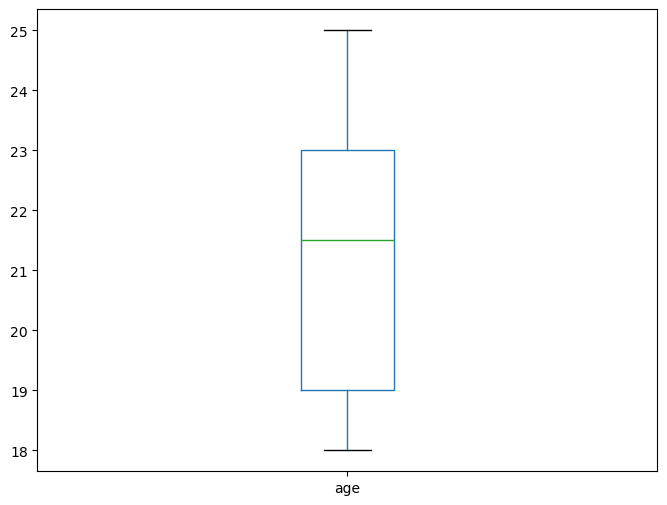

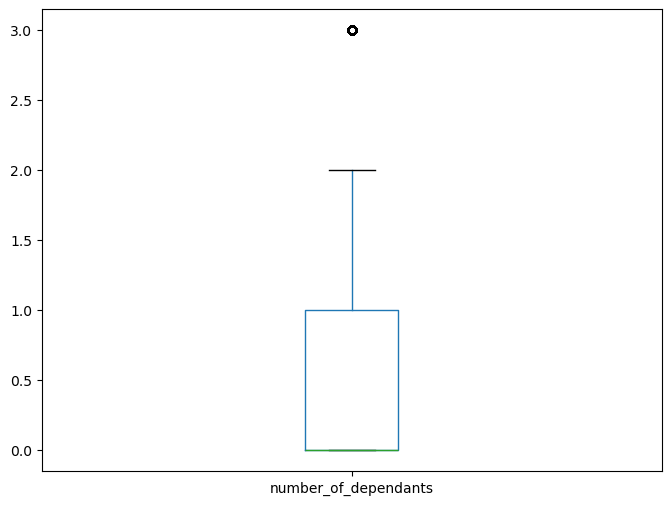

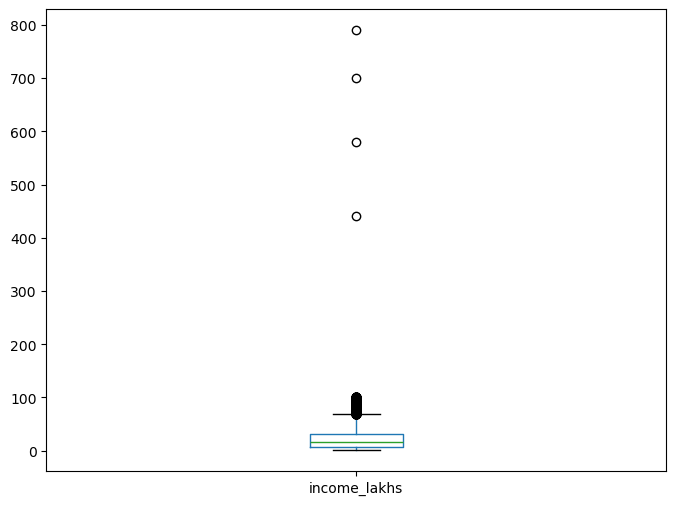

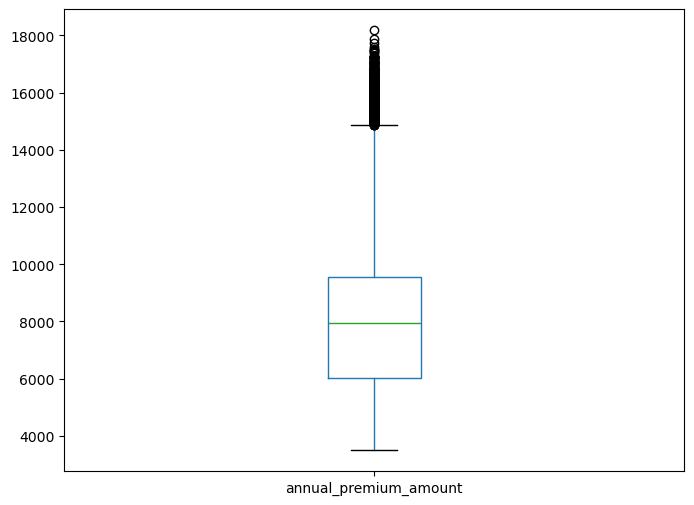

In [25]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
  df.boxplot(column=col, grid=False, figsize=(8, 6))
  plt.show()

In [26]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_iqr(df, 'age')

In [27]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.722582,22.506519,8141.941033
std,2.294050,0.937255,23.418644,2749.609551
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [28]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking' 'Unknown']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [29]:
df.duplicated().sum()

0

In [30]:
df['smoking_status'] = df['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional', 'Unknown'], dtype=object)

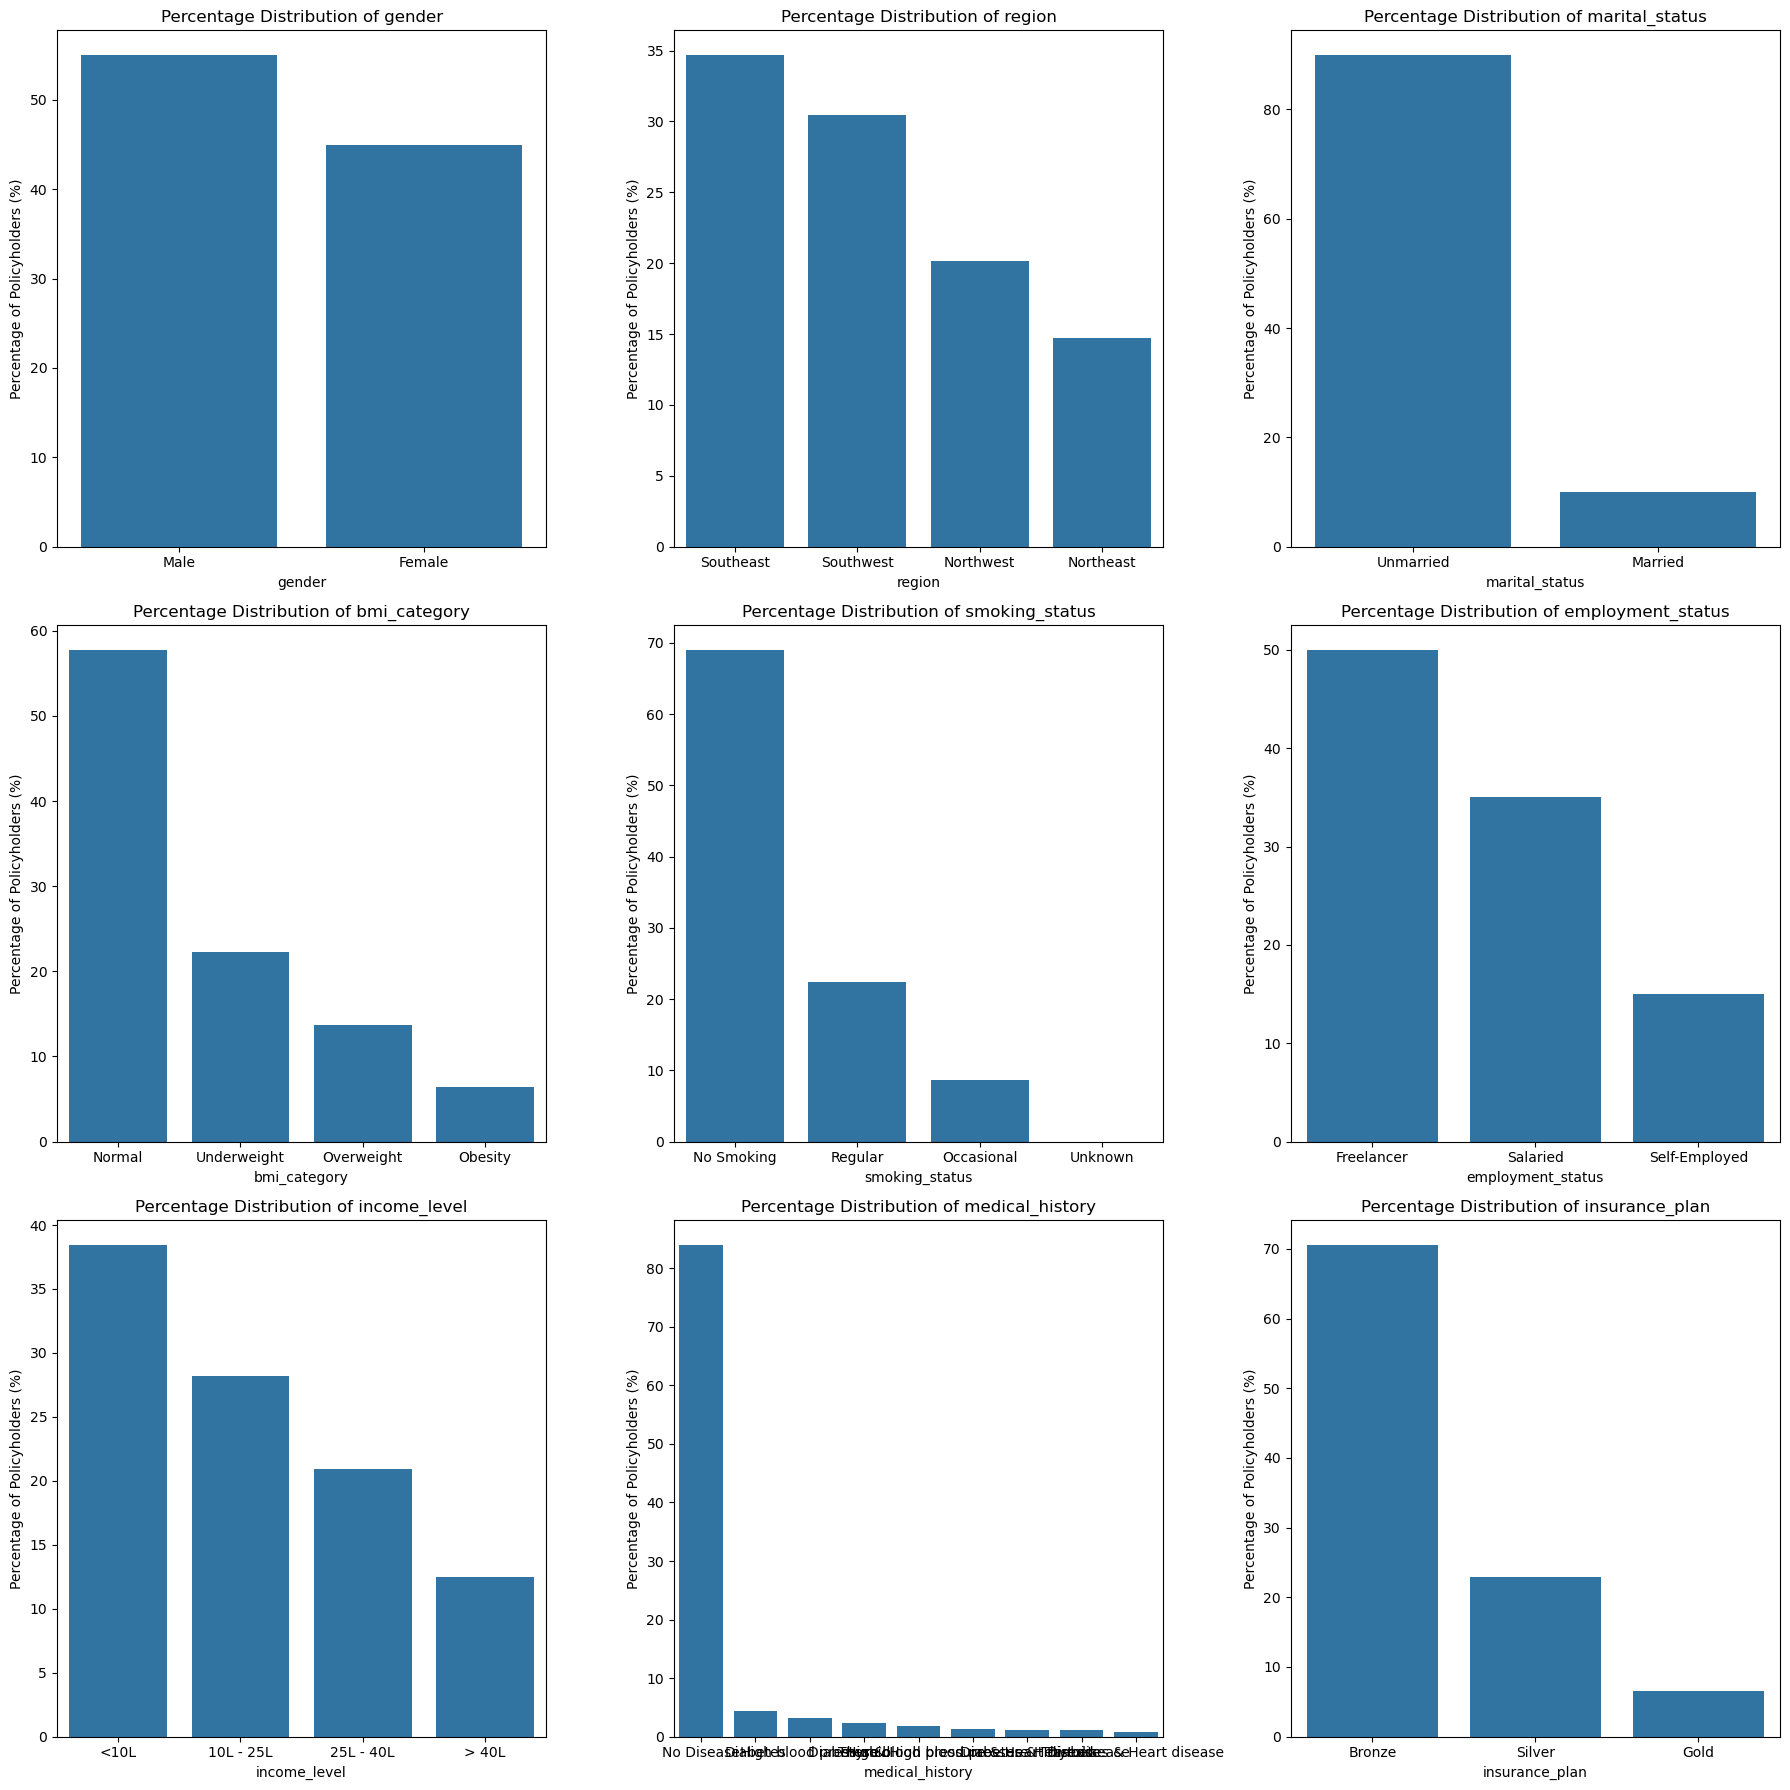

In [31]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies

    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

In [32]:
crosstab = pd.crosstab(df['income_level'], df['insurance_plan'])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4509   326     828
25L - 40L         3382   209     608
<10L              6175   404    1147
> 40L              116   366    2026


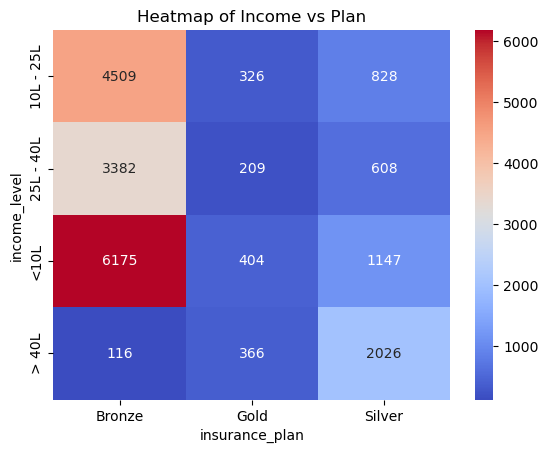

In [33]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

In [34]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df[['disease1', 'disease2']] = df['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df['disease1'] = df['disease1'].fillna('none')
df['disease2'] = df['disease2'].fillna('none')
df['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score) / (max_score - min_score)
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,none,0,0.000000


In [35]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [36]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [37]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,1,0,1,0,0,1,0,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,1,0,0,1,0,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,0,1,0,0,0,0,1,0,1,0


In [38]:
df = df.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0,0
2,21,0,4,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,0,1,0


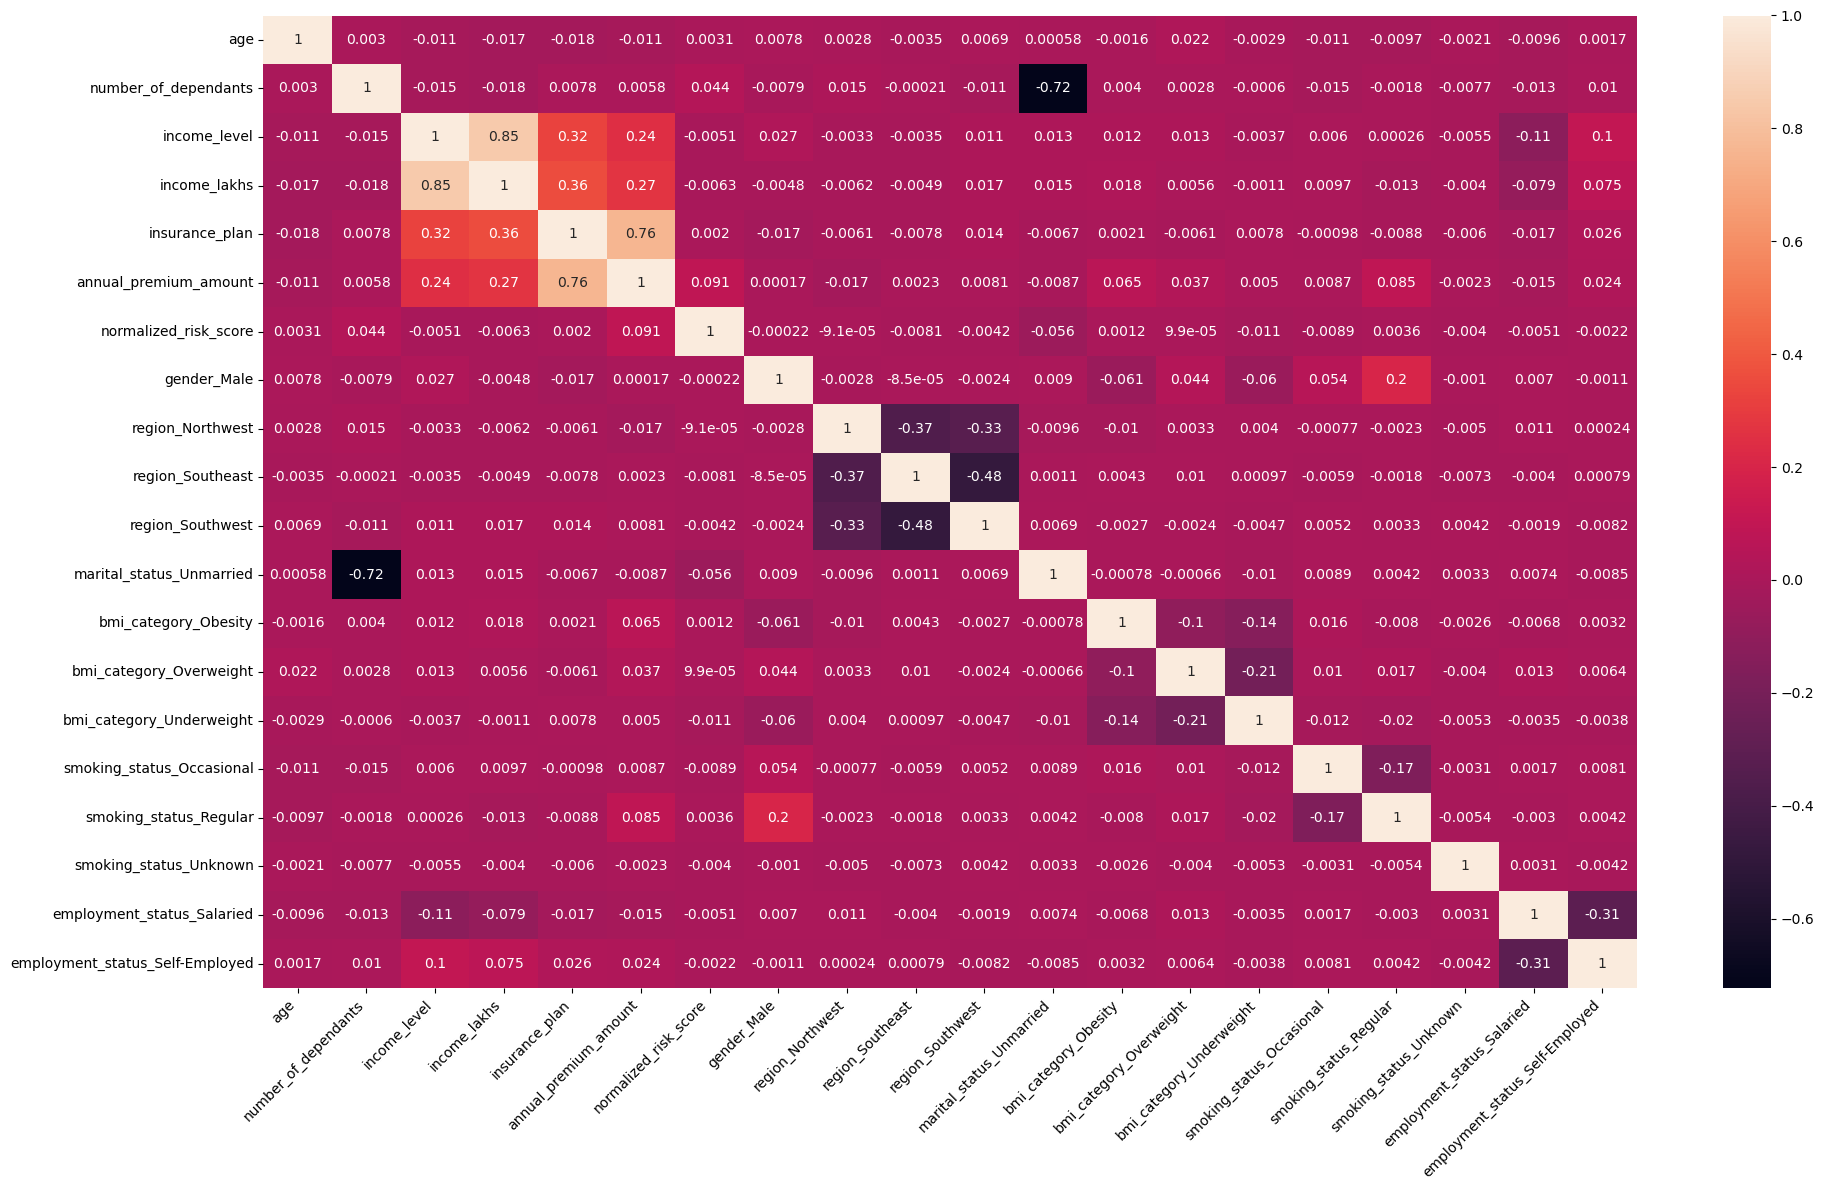

In [39]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
X = df.drop('annual_premium_amount', axis='columns')
y = df['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,0.499147,0.240861,0.358031,0.027258,0.179613,0.092047,0.550259,0.201234,0.346935,0.304688,0.899881,0.063545,0.136495,0.222482,0.086485,0.223477,0.000100,0.350020,0.149930
std,0.327721,0.312418,0.347558,0.029681,0.300032,0.229974,0.497480,0.400933,0.476007,0.460286,0.300167,0.243947,0.343322,0.415924,0.281086,0.416586,0.009976,0.476988,0.357012
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.006337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.000000,0.333333,0.019011,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.038023,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [42]:
calculate_vif(X)

,Column,VIF
0,age,3.142961
1,number_of_dependants,1.860454
2,income_level,7.595150
3,income_lakhs,6.935048
4,insurance_plan,1.556809
5,normalized_risk_score,1.154197
6,gender_Male,2.309048
7,region_Northwest,2.147797
8,region_Southeast,2.970657
9,region_Southwest,2.731400


In [43]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,3.141479
1,number_of_dependants,1.854136
2,income_lakhs,2.101895
3,insurance_plan,1.553840
4,normalized_risk_score,1.154152
5,gender_Male,2.298485
6,region_Northwest,2.146557
7,region_Southeast,2.968901
8,region_Southwest,2.730231
9,marital_status_Unmarried,7.265502


In [44]:
# # we will drop income_lakhs due to high VIF value
# X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (14067, 19)
x test:  (6029, 19)
y train:  (14067,)
y test:  (6029,)


In [46]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.6029024254544584, 0.6030094778265316)

In [47]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  3031419.762811617 RMSE:  1741.0972870036921


In [48]:
X_test.shape

(6029, 19)

In [49]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([  66.306573,  -98.039461,  -31.917488,  321.704891, 6975.521462,
       1027.512718,  -18.120958,  -76.220485,    9.842327,  -28.547956,
        -78.41979 ,  777.51678 ,  404.242703,  170.414344,  227.209763,
        618.699266,  986.464817,   13.699294,   -5.399528])

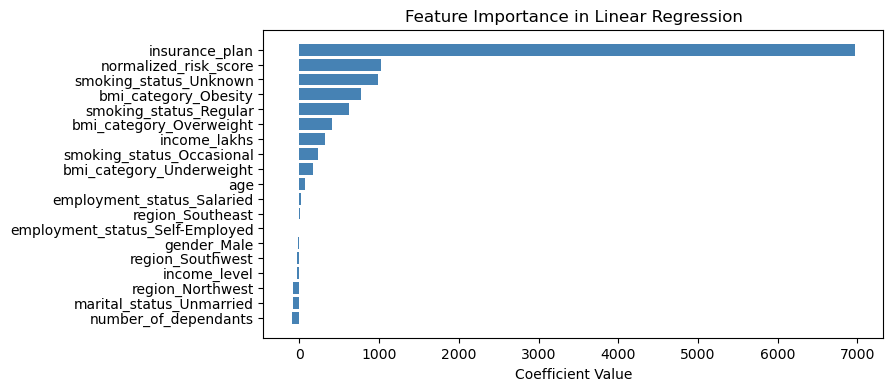

In [50]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [51]:
# Ridge Regression Model
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.6028998324747529, 0.6029955452393496)

In [52]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  3031526.1520520938 RMSE:  1741.1278390893915


In [53]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.6006647112523398

In [54]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  3049324.4011724265 RMSE:  1746.2314855632476


In [55]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=None)
random_search.fit(X_train, y_train)
random_search.best_score_

0.5997747668291069

In [56]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}

In [57]:
best_model = random_search.best_estimator_

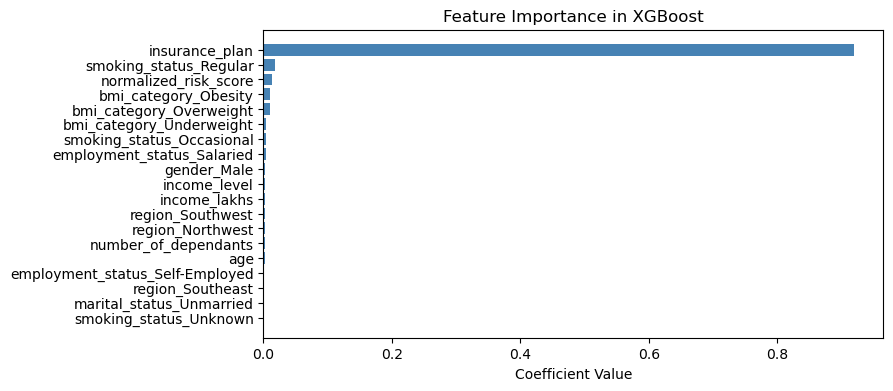

In [58]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [59]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
4797,6696,6594.937500,-101.062500,-1.509297
14476,10073,7643.399414,-2429.600586,-24.119930
11142,9524,11235.514648,1711.514648,17.970544
15008,4553,7063.676270,2510.676270,55.143340
18245,8814,6982.229004,-1831.770996,-20.782516


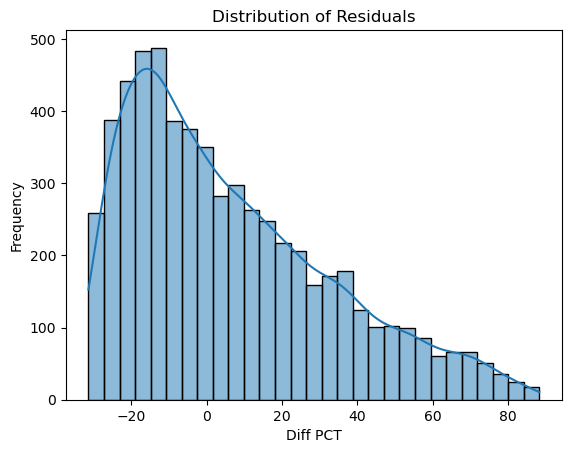

In [60]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [61]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
14476,10073,7643.399414,-2429.600586,-24.119930
11142,9524,11235.514648,1711.514648,17.970544
15008,4553,7063.676270,2510.676270,55.143340
18245,8814,6982.229004,-1831.770996,-20.782516
12515,9003,6594.937500,-2408.062500,-26.747334


In [62]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

73.22939127550174

In [63]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
10165,3501,6594.937500,3093.937500,88.372965
7624,3502,6594.937500,3092.937500,88.319175
10296,3526,6586.267578,3060.267578,86.791480
19094,3531,6594.937500,3063.937500,86.772515
4169,3517,6558.913574,3041.913574,86.491714
...,...,...,...,...
16173,4391,6594.937500,2203.937500,50.192154
12885,4647,6978.099609,2331.099609,50.163538
6072,4419,6634.597168,2215.597168,50.137976
7971,4812,7224.381348,2412.381348,50.132613


In [64]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
14476,0.428571,1.000000,0.666667,0.035488,0.0,1.0,1,1,0,0,0,0,0,0,0,0,0,0,0
11142,1.000000,0.333333,1.000000,0.051965,0.5,0.0,1,0,0,1,1,1,0,0,0,1,0,0,1


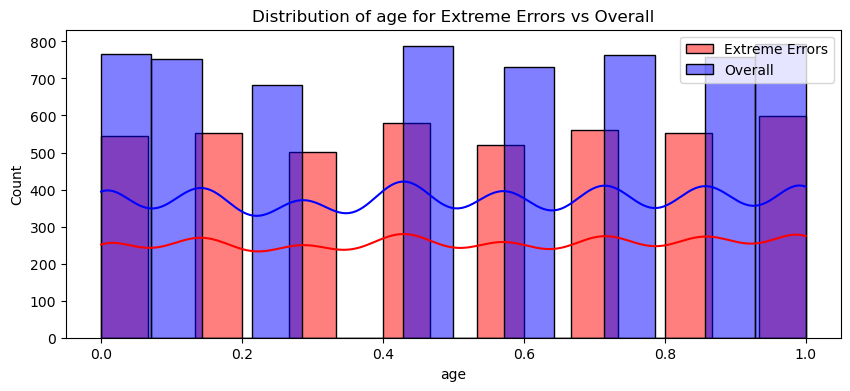

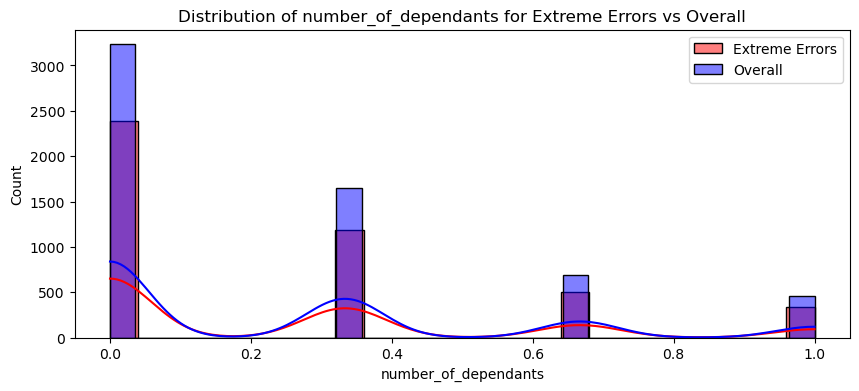

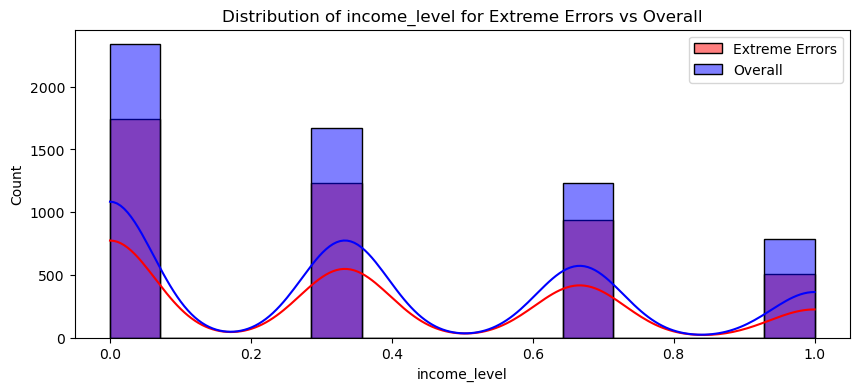

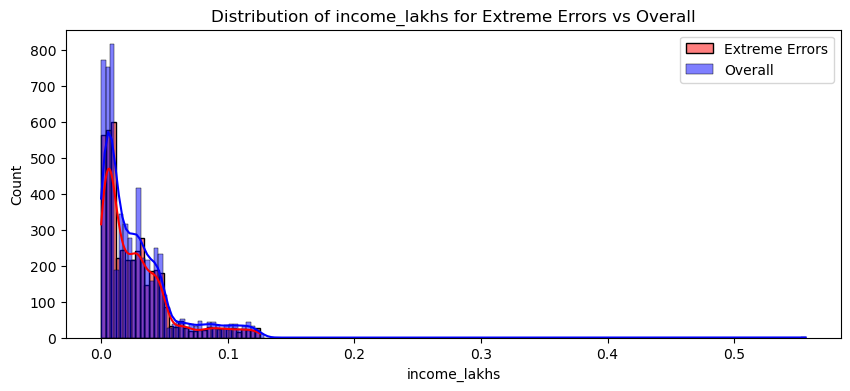

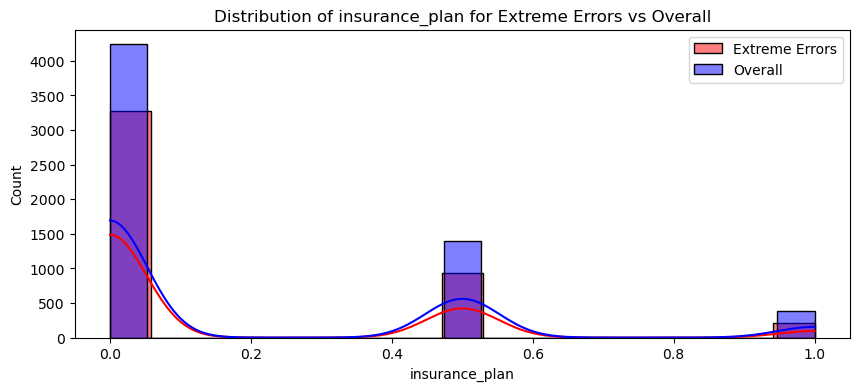

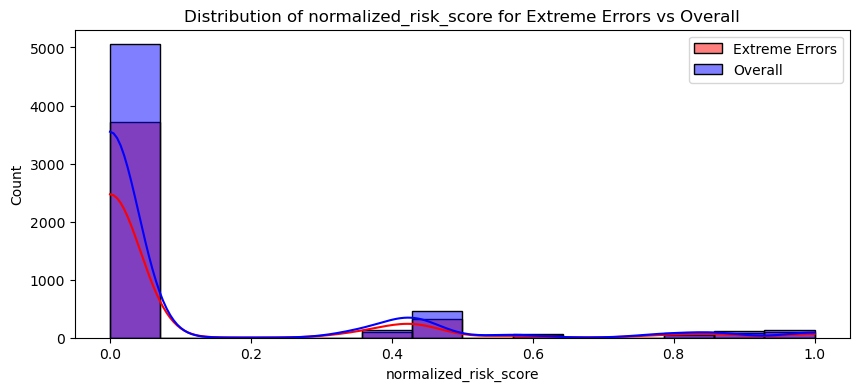

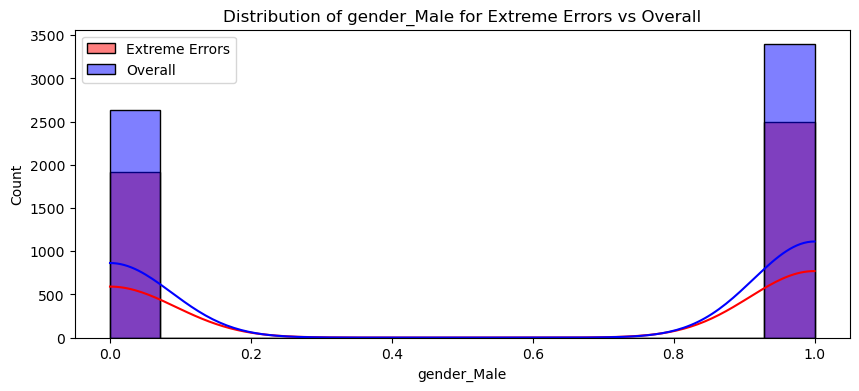

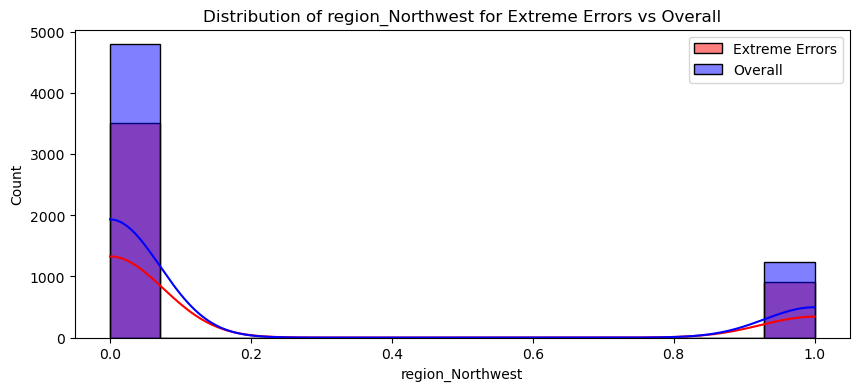

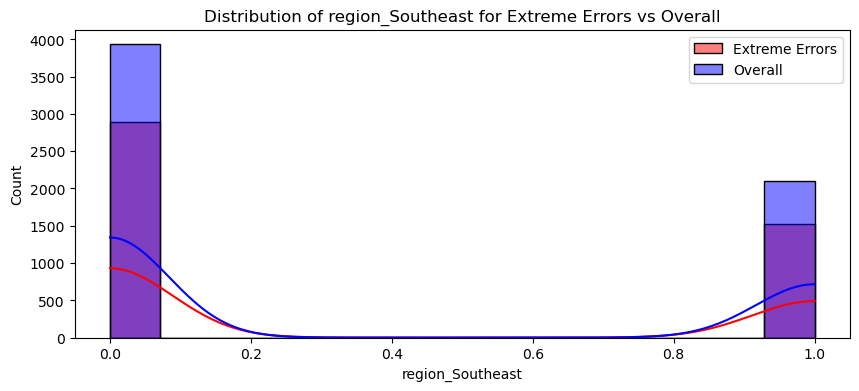

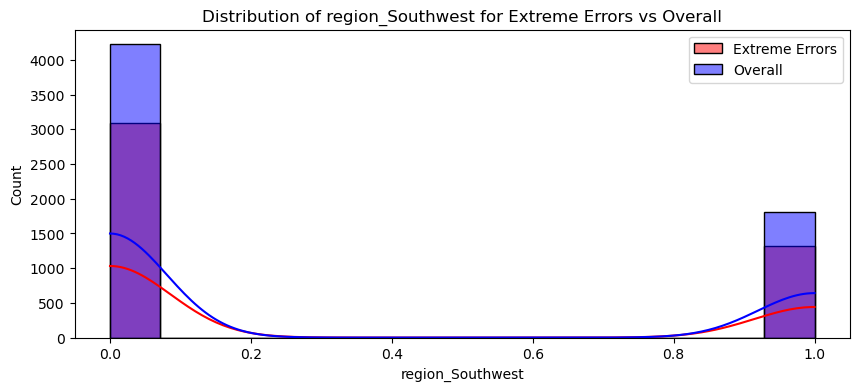

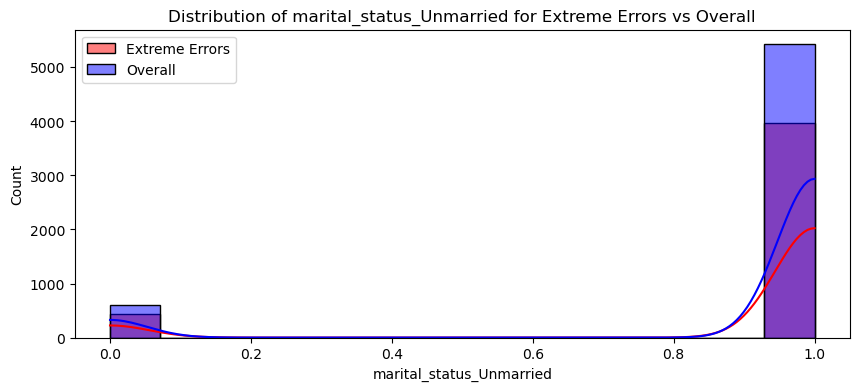

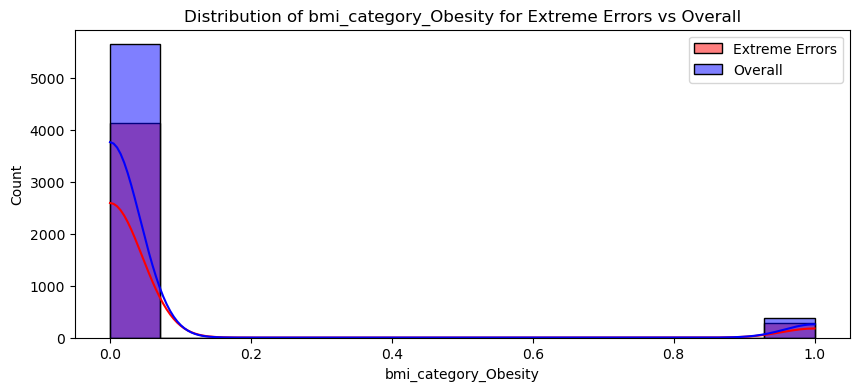

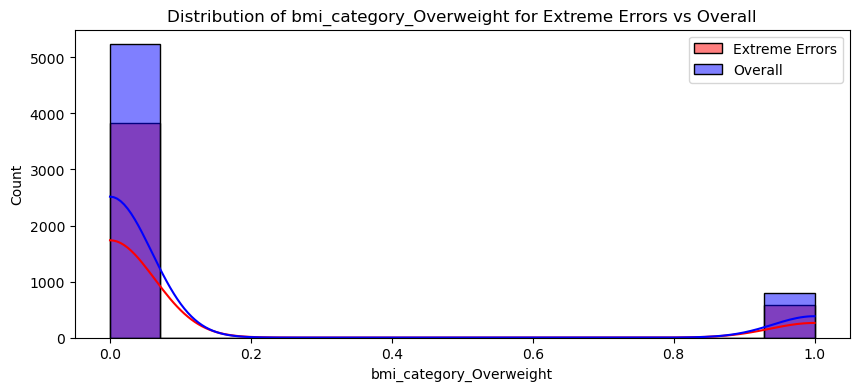

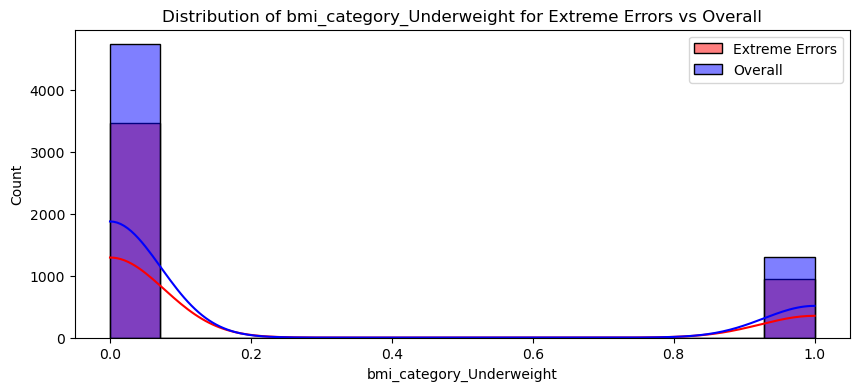

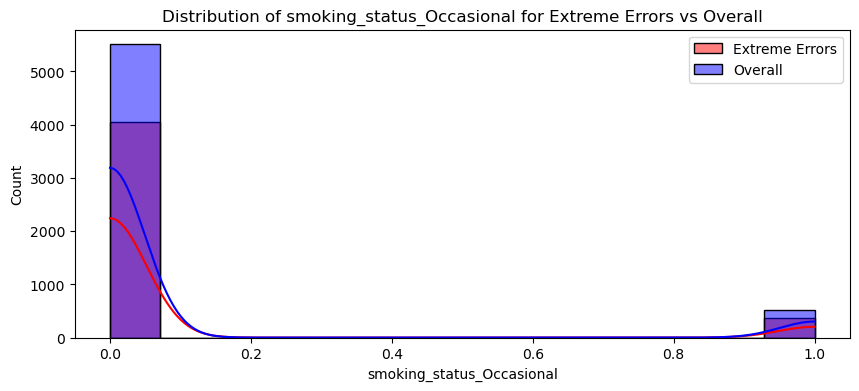

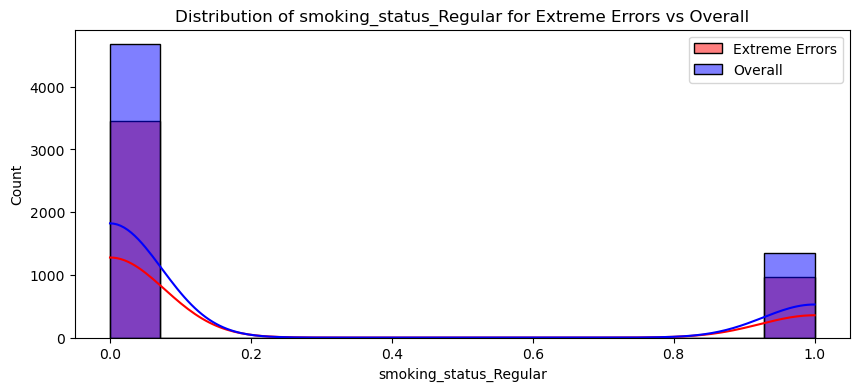

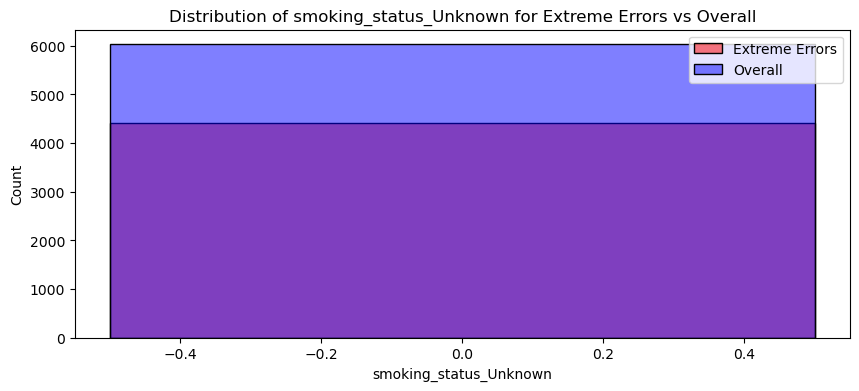

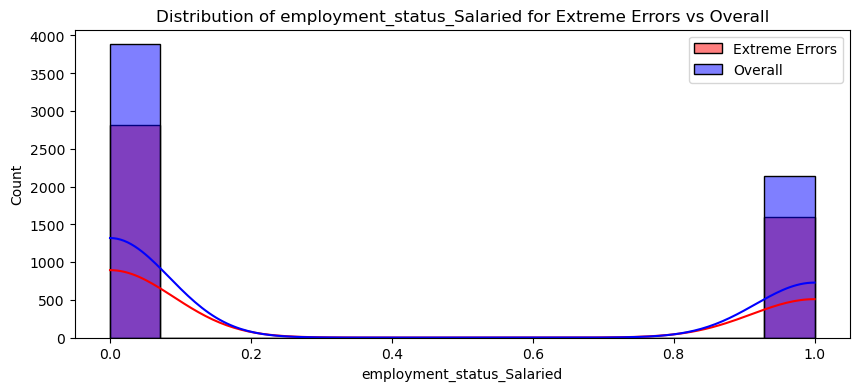

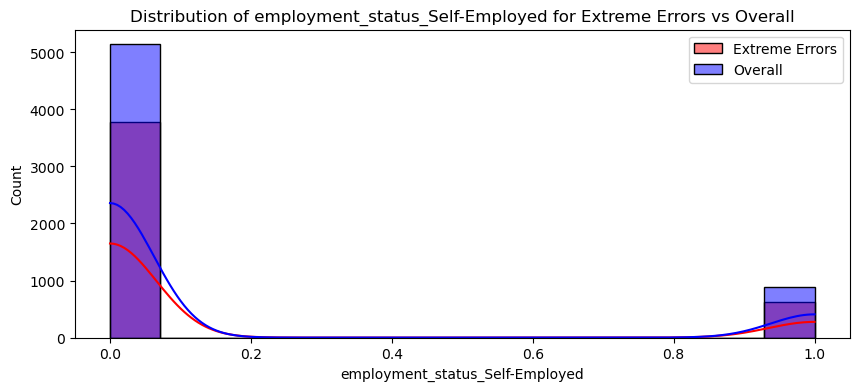

In [65]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [66]:
# extreme_errors_df['income_level']=-1

In [67]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,21.0,3.0,3.0,29.0,1.0
1,25.0,1.0,4.0,42.0,2.0
2,25.0,0.0,1.0,1.0,1.0
3,20.0,0.0,3.0,26.0,1.0
4,22.0,1.0,2.0,11.0,1.0


In [68]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4415.000000,4415.000000,4415.000000,4415.000000,4415.000000
mean,21.555832,0.726614,2.046659,21.623103,1.305549
std,2.311394,0.941543,1.030613,20.918439,0.554427
min,18.000000,0.000000,1.000000,1.000000,1.000000
25%,20.000000,0.000000,1.000000,6.000000,1.000000
50%,22.000000,0.000000,2.000000,16.000000,1.000000
75%,24.000000,1.000000,3.000000,31.000000,2.000000
max,25.000000,3.000000,4.000000,100.000000,3.000000


In [69]:
df_reversed['age']

0       21.0
1       25.0
2       25.0
3       20.0
4       22.0
        ... 
4410    19.0
4411    21.0
4412    20.0
4413    21.0
4414    19.0
Name: age, Length: 4415, dtype: float64

In [70]:
df_reversed['age'].quantile(q=0.97)

25.0

In [71]:
sns.histplot(df_reversed.age)

<Axes: xlabel='age', ylabel='Count'>

This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment